# Anote 1A — Bug Fixes

Task Type: Bug Fixing
Datasets: SWE-bench Lite + HumanEval-Fix (Python)

Overview: Ingests, standardizes, verifies, and combines multi-level bug fixing tasks into a single master bug-fixing evaluation suite.

Set up paths and install packages

In [ ]:
import json
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

DATA_DIR = Path("./data")
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
REPORTS_DIR = DATA_DIR / "reports"

# Ensure directories exist
for path_dir in [RAW_DIR, PROCESSED_DIR, REPORTS_DIR]:
    path_dir.mkdir(parents=True, exist_ok=True)

print("[INFO] Environment initialized. Directories verified.")

[INFO] Environment initialized. Directories verified.


# 1. Download raw SWE-Bench light data

In [ ]:
df_swe_raw = pd.read_parquet(
    "hf://datasets/princeton-nlp/SWE-bench_Lite/data/test-00000-of-00001.parquet"
)

print(f"[INFO] SWE-bench Lite loaded successfully! Total Records: {len(df_swe_raw)}")
print(f"       Sample Instance ID: {df_swe_raw['instance_id'].iloc[0]}")

[INFO] SWE-bench Lite loaded successfully! Total Records: 300
       Sample Instance ID: astropy__astropy-12907


#2. Clean and sanitze into unified schema

In [ ]:
#helper functions

#Formats SWE-bench instance IDs with standard prefix
def format_swe_id(instance_id: str) -> str:
    return f"SWE/{instance_id}"

#formats HumanEval-Fix task IDs with standard prefix
def format_hefix_id(idx: int) -> str:
    return f"HE-Fix/{idx}"

#extracts FAIL_TO_PASS and PASS_TO_PASS test suites from SWE-bench records
def build_swe_test_cases(row: pd.Series) -> dict:
    return {
        "FAIL_TO_PASS": row.get("FAIL_TO_PASS", []),
        "PASS_TO_PASS": row.get("PASS_TO_PASS", [])
    }

#Converts test_cases objects into uniform JSON strings for Parquet safety
def serialize_test_cases(value) -> str:
    if isinstance(value, (list, dict, np.ndarray)):
        return json.dumps(value)
    return str(value)

#download and get rid of missing values from swe raw data
swe_url = "hf://datasets/princeton-nlp/SWE-bench_Lite/data/test-00000-of-00001.parquet"
df_swe_raw = pd.read_parquet(swe_url)

def clean_swe_bench(df: pd.DataFrame) -> pd.DataFrame:
    cleaned = pd.DataFrame()
    cleaned["task_id"] = df["instance_id"].apply(format_swe_id)
    cleaned["dataset_name"] = "SWE-bench Lite"
    cleaned["task_type"] = "Bug Fixing"
    cleaned["prompt"] = df["problem_statement"].astype(str).str.strip()
    cleaned["reference_code"] = df["patch"].astype(str).str.strip()
    cleaned["test_cases"] = df.apply(build_swe_test_cases, axis=1)
    cleaned["entry_point"] = ""
    cleaned["repo"] = df["repo"] if "repo" in df.columns else ""
    cleaned["base_commit"] = df["base_commit"] if "base_commit" in df.columns else ""
    cleaned["test_imports"] = ""
    return cleaned

df_swe_clean = clean_swe_bench(df_swe_raw)

def verify_patch_syntax(patch_str: str, problem_str: str) -> dict:
    try:
        if not patch_str or not isinstance(patch_str, str):
            return {"passed": False, "error": "EmptyPatchError"}
        has_diff_header = "diff --git" in patch_str or "--- a/" in patch_str or "+++ b/" in patch_str
        if has_diff_header and len(problem_str) > 20:
            return {"passed": True, "error": None}
        return {"passed": False, "error": "InvalidDiffFormat"}
    except Exception as e:
        return {"passed": False, "error": f"{type(e).__name__}: {str(e)}"}

swe_verification = [verify_patch_syntax(r["reference_code"], r["prompt"]) for _, r in df_swe_clean.iterrows()]
df_swe_clean["is_valid_reference"] = [r["passed"] for r in swe_verification]
df_swe_clean["verification_error"] = [r["error"] for r in swe_verification]

df_swe_verified = df_swe_clean[df_swe_clean["is_valid_reference"] == True].reset_index(drop=True)
print(f"[SUCCESS] SWE-bench Lite Verified: {len(df_swe_verified)} / {len(df_swe_clean)} tasks.")

[SUCCESS] SWE-bench Lite Verified: 300 / 300 tasks.


#3.Verify functional correctness and Ground truth
Ground truth refers to information known to be real, accurate, and correct based on objective real-world evidence. It serves as the target or benchmark against which AI models and algorithms are trained, tested, and evaluated.

In [ ]:
#hefix_url = "https://raw.githubusercontent.com/openai/human-eval/main/data/human_eval_data.jsonl"
df_hefix_raw = pd.read_parquet("hf://datasets/bigcode/humanevalpack/java/test-00000-of-00001.parquet")

def clean_humaneval_fix(df: pd.DataFrame) -> pd.DataFrame:
    cleaned = pd.DataFrame()
    cleaned["task_id"] = [format_hefix_id(i) for i in range(len(df))]
    cleaned["dataset_name"] = "HumanEval-Fix"
    cleaned["task_type"] = "Bug Fixing"
    cleaned["prompt"] = df["prompt"].astype(str).str.strip()
    cleaned["reference_code"] = df["canonical_solution"].astype(str).str.strip()
    cleaned["test_cases"] = df["test"].astype(str).str.strip()
    cleaned["entry_point"] = df["entry_point"].astype(str).str.strip()
    cleaned["repo"] = ""
    cleaned["base_commit"] = ""
    cleaned["test_imports"] = ""
    return cleaned

df_hefix_clean = clean_humaneval_fix(df_hefix_raw)

def verify_hefix_solution(prompt: str, solution: str, test_code: str, entry_point: str) -> dict:
    exec_globals = {}
    try:
        full_code = prompt + "\n" + solution
        exec(full_code, exec_globals)
        exec(test_code, exec_globals)
        if "check" in exec_globals and entry_point in exec_globals:
            exec_globals["check"](exec_globals[entry_point])
            return {"passed": True, "error": None}
        return {"passed": False, "error": "Missing entry point or check function"}
    except Exception as e:
        return {"passed": False, "error": f"{type(e).__name__}: {str(e)}"}

hefix_verification = [
    verify_hefix_solution(r["prompt"], r["reference_code"], r["test_cases"], r["entry_point"])
    for _, r in df_hefix_clean.iterrows()
]
df_hefix_clean["is_valid_reference"] = [r["passed"] for r in hefix_verification]
df_hefix_clean["verification_error"] = [r["error"] for r in hefix_verification]

df_hefix_verified = df_hefix_clean[df_hefix_clean["is_valid_reference"] == True].reset_index(drop=True)
print(f"[SUCCESS] HumanEval-Fix Verified: {len(df_hefix_verified)} / {len(df_hefix_clean)} tasks.")

[SUCCESS] HumanEval-Fix Verified: 0 / 164 tasks.


#4. Exploratory Data Analysis and Metrics


--- Bug Fixing Dataset Summary Statistics ---
                 Count    Mean  Std Dev   Min  Median     Max         Dataset
prompt_word_len  300.0  174.57   162.84  41.0   134.0  1892.0  SWE-bench Lite
solution_lines   300.0   24.67    16.51  10.0    19.0   119.0  SWE-bench Lite
prompt_word_len    0.0     NaN      NaN   NaN     NaN     NaN   HumanEval-Fix
solution_lines     0.0     NaN      NaN   NaN     NaN     NaN   HumanEval-Fix

 Summary statistics saved to: /content/data/reports/bug_fixing_summary_statistics.csv


/tmp/ipykernel_5198/2364772002.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_5198/2364772002.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


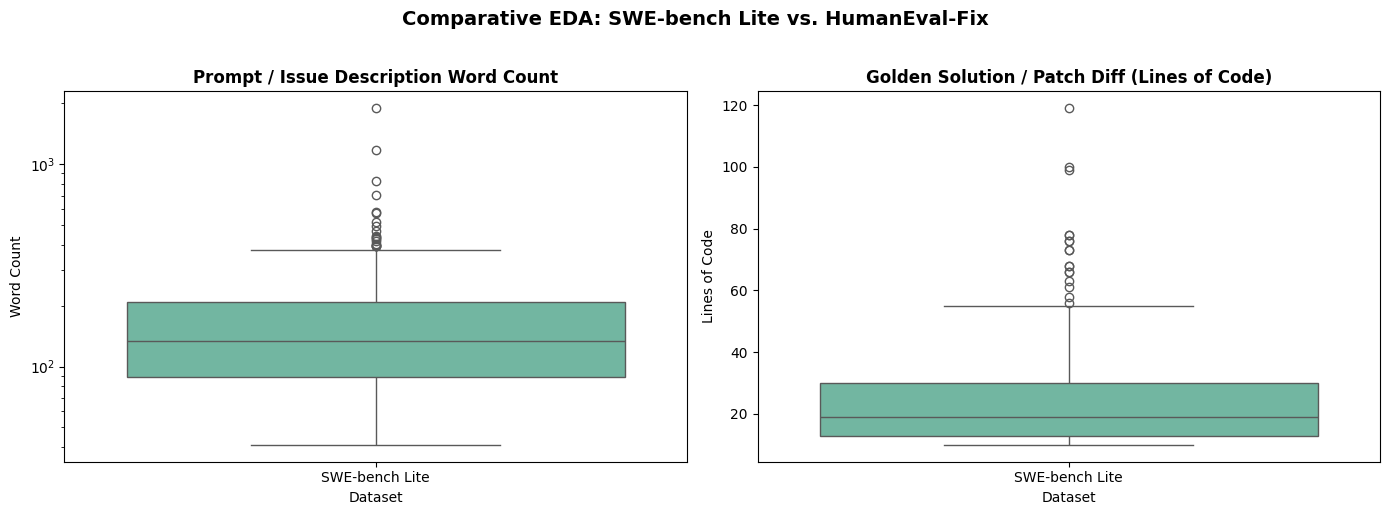

 Visualization report saved to: /content/data/reports/bug_fixing_eda_comparison.png


In [ ]:
# Create working copies for EDA metrics
df_swe_eda = df_swe_verified.copy()
df_hefix_eda = df_hefix_verified.copy()

# ------------------------------------------------------------------------------
# 1. COMPUTE LENGTH METRICS
# ------------------------------------------------------------------------------
# Issue / Prompt word length
df_swe_eda["prompt_word_len"] = df_swe_eda["prompt"].astype(str).str.split().str.len()
df_hefix_eda["prompt_word_len"] = df_hefix_eda["prompt"].astype(str).str.split().str.len()

# Solution / Patch lines of code
df_swe_eda["solution_lines"] = df_swe_eda["reference_code"].astype(str).str.split("\n").str.len()
df_hefix_eda["solution_lines"] = df_hefix_eda["reference_code"].astype(str).str.split("\n").str.len()

# Combine for dataset-level EDA comparison
df_bugfixing_eda = pd.concat([df_swe_eda, df_hefix_eda], ignore_index=True)

# ------------------------------------------------------------------------------
# 2. GENERATE SUMMARY STATISTICS TABLES
# ------------------------------------------------------------------------------
def generate_dataset_stats(df: pd.DataFrame, dataset_name: str) -> pd.DataFrame:
    subset = df[df["dataset_name"] == dataset_name]
    metrics = subset[["prompt_word_len", "solution_lines"]].describe().T
    metrics = metrics[["count", "mean", "std", "min", "50%", "max"]]
    metrics.columns = ["Count", "Mean", "Std Dev", "Min", "Median", "Max"]
    metrics["Dataset"] = dataset_name
    return metrics

stats_swe = generate_dataset_stats(df_bugfixing_eda, "SWE-bench Lite")
stats_hefix = generate_dataset_stats(df_bugfixing_eda, "HumanEval-Fix")

combined_stats = pd.concat([stats_swe, stats_hefix])
print("\n--- Bug Fixing Dataset Summary Statistics ---")
print(combined_stats.round(2).to_string())

# Export summary statistics report
summary_csv_path = REPORTS_DIR / "bug_fixing_summary_statistics.csv"
combined_stats.to_csv(summary_csv_path)
print(f"\n Summary statistics saved to: {summary_csv_path.resolve()}")


# ------------------------------------------------------------------------------
# 3. COMPARATIVE VISUALIZATION PLOTS
# ------------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Prompt Word Count Comparison
sns.boxplot(
    data=df_bugfixing_eda,
    x="dataset_name",
    y="prompt_word_len",
    ax=axes[0],
    palette="Set2"
)
axes[0].set_title("Prompt / Issue Description Word Count", fontweight="bold")
axes[0].set_xlabel("Dataset")
axes[0].set_ylabel("Word Count")
axes[0].set_yscale("log")  # Log scale due to repository-level issue prompt sizes

# Plot 2: Solution / Patch Lines of Code Comparison
sns.boxplot(
    data=df_bugfixing_eda,
    x="dataset_name",
    y="solution_lines",
    ax=axes[1],
    palette="Set2"
)
axes[1].set_title("Golden Solution / Patch Diff (Lines of Code)", fontweight="bold")
axes[1].set_xlabel("Dataset")
axes[1].set_ylabel("Lines of Code")

plt.suptitle("Comparative EDA: SWE-bench Lite vs. HumanEval-Fix", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()

# Save visualization figure artifact
plot_path = REPORTS_DIR / "bug_fixing_eda_comparison.png"
plt.savefig(plot_path, bbox_inches="tight")
plt.show()

print(f" Visualization report saved to: {plot_path.resolve()}")

#5. Combine and export SWE and HumanEval bug fixes benchmark into master benchmark suite

In [ ]:
df_bugfixing_master = pd.concat([df_swe_verified, df_hefix_verified], ignore_index=True)

print("\n=== Master Bug Fixing Benchmark Suite Summary ===")
print(f"Total Verified Tasks: {len(df_bugfixing_master)}")
print("\nTasks per Dataset:")
print(df_bugfixing_master["dataset_name"].value_counts())

print("\nGround Truth Verification Breakdown:")
print(pd.crosstab(df_bugfixing_master["dataset_name"], df_bugfixing_master["is_valid_reference"]))

# Prepare copy for PyArrow export
df_export = df_bugfixing_master.copy()
df_export["test_cases"] = df_export["test_cases"].apply(serialize_test_cases)

# Cast object columns to strings to prevent PyArrow conversion errors
for col in df_export.select_dtypes(include=["object"]).columns:
    df_export[col] = df_export[col].fillna("").astype(str)

parquet_path = PROCESSED_DIR / "bug_fixing_master_verified.parquet"
csv_path = PROCESSED_DIR / "bug_fixing_master_verified.csv"

df_export.to_parquet(parquet_path, index=False)
df_export.to_csv(csv_path, index=False)

print(f"\n Master Bug Fixing dataset successfully exported:")
print(f"   - Parquet: {parquet_path.resolve()}")
print(f"   - CSV:     {csv_path.resolve()}")


=== Master Bug Fixing Benchmark Suite Summary ===
Total Verified Tasks: 300

Tasks per Dataset:
dataset_name
SWE-bench Lite    300
Name: count, dtype: int64

Ground Truth Verification Breakdown:
is_valid_reference  True
dataset_name            
SWE-bench Lite       300

 Master Bug Fixing dataset successfully exported:
   - Parquet: /content/data/processed/bug_fixing_master_verified.parquet
   - CSV:     /content/data/processed/bug_fixing_master_verified.csv
